# Tráfico en Madrid: Entrenamiento y optimización de modelos

En este notebook usamos los datos que hemos preparado antes. Directamente entrenamos cuatro modelos (incluido un baseline simple para tener una referencia), comparamos su rendimiento en validación, elegimos el mejor y ajustamos sus hiperparámetros. Al final guardamos un único pipeline para que el NB04 lo use en la evaluación final con test.

Vamos a tener en cuenta tanto los resultados finales como el tiempo en entrenar como todos los parámetros.

Todo esto está probado solo cargando los datos de 2026, al final ya con el modelo con los mejores parámetros ya si que cargamos  2025 y 2026 para tener muchos más datos de entrenamiento. Si mi ordenador lo permite probaremos con los 3 años.

# 1. Configuración del entorno

Igual que en los otros notebooks, dejamos aqui al principio todo lo que necesitamos.

In [1]:
%pip install -r ../requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Librería estándar
import time
import json
from pathlib import Path

# Terceros
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

Usamos directamente los parquet ya procesados que dejó el NB02 en final y nos centramos en entrenar modelos. 

Definimos todas las constantes que hemos estado usando hasta ahora y las necesarias para estos modelos además de elegir las features para los modelos. En este caso quitamos ID ya que no va a aportar nada al modelo ya con las coordenadas y distrito sabemos que sensor es cada uno. Igualmente lo hemos guardado en el parquet para poder luego analizar datos de cada sensor y no perder info.

También fijamos `TAM_MUESTRA_BUSQUEDA` = 2_000_000 para la optimización de hiperparámetros. Lo hacemos así porque la búsqueda usa 30 iteraciones con cv=3 (90 entrenamientos), y hacer eso sobre todo el train completo sería demasiado costoso. Probamos distintos tamaños y vimos que 2M es un buen equilibrio: con menos muestra (por ejemplo 1M) el F1 era más inestable entre folds, y con más (por ejemplo 5M) el tiempo subía mucho sin una mejora clara. Por eso usamos 2M para buscar parámetros de forma robusta y luego reentrenamos el modelo ganador con todos los datos.

In [3]:
RANDOM_STATE = 42

DATA_FINAL = Path("../data/final")
RUTA_MODELO = DATA_FINAL / "modelo_congestion.joblib"
RUTA_METADATOS = DATA_FINAL / "modelo_metadatos.json"

FEATURES_MODELO = [
    "tipo_elem",
    "distrito",
    "utm_x",
    "utm_y",
    "hora",
    "dia_semana",
    "es_laborable",
    "es_hora_punta",
]
COLS_CICLICAS = ["hora", "dia_semana"]
COLS_CONTINUAS = ["utm_x", "utm_y"]
COL_CATEGORICA = ["distrito"]
COLS_PASSTHROUGH = ["tipo_elem", "es_laborable", "es_hora_punta"]

TAM_MUESTRA_BUSQUEDA = 2_000_000

Los ajustes de pandas y matplotlib.

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="ticks", palette="muted", font_scale=0.9)
plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.35,
    }
)

_pal = sns.color_palette("muted")
COLOR_AZUL = _pal[0]
COLOR_NARANJA = _pal[1]
COLOR_VERDE = _pal[2]
COLOR_ROJO = _pal[3]

# 2. Carga de los datos

Cargamos train y validación desde los parquets que dejó el NB02. El test set no lo tocamos aquí: es para la evaluación definitiva del NB04.

In [5]:
def cargar_split(nombre: str):
    X = pd.read_parquet(DATA_FINAL / f"X_{nombre}.parquet")
    y = pd.read_parquet(DATA_FINAL / f"y_{nombre}.parquet").squeeze("columns")
    X = X.drop(columns=["id"])
    return X[FEATURES_MODELO], y


X_train, y_train = cargar_split("train")
X_val, y_val = cargar_split("val")

print(list(X_train.columns))

['tipo_elem', 'distrito', 'utm_x', 'utm_y', 'hora', 'dia_semana', 'es_laborable', 'es_hora_punta']


# 3. Estrategia de evaluación para clases desbalanceadas

Con datos desbalanceados (95/5), la accuracy engaña: un modelo que predijera siempre "no congestionado" tendría 95% de acierto sin haber aprendido nada. Por eso usamos métricas que importan realmente para este problema.

**Recall:** de los atascos reales, cuántos detecta el modelo. Un recall bajo significa atascos no avisados.

**Precision:** de los atascos que predice, cuántos son reales. Precision baja = falsas alarmas.

**F1:** combina recall y precision. Es nuestra métrica principal porque equilibra detectar atascos sin saturar con falsas alarmas.

**PR-AUC:** área bajo la curva precision-recall. Es mejor que ROC-AUC cuando hay desbalance.

**ROC-AUC:** lo calculamos como referencia, aunque puede ser optimista.

Calcularemos las cinco métricas para todos los modelos, pero elegimos el ganador por F1.

Función para calcular todas las métricas.

Antes de calcular métricas, sacamos dos salidas del modelo: la clase predicha con `predict` y la probabilidad de congestión con `predict_proba`. `predict_proba` devuelve dos columnas por fila: P(fluido) y P(congestionado). Aquí usamos `[:, 1]` para quedarnos con P(congestionado), que es la clase positiva que queremos detectar.

Esta probabilidad no es el porcentaje de acierto del modelo. Es la confianza del modelo para ese caso concreto. Como esta función se aplica a los cuatro pipelines, esta lógica vale para LogReg, Random Forest, HistGBM y Dummy.

Gracias a esta salida podemos calcular PR-AUC y ROC-AUC, comparar mejor modelos desbalanceados y, más adelante, ajustar el umbral si queremos menos falsas alarmas o más detección de atascos.

In [6]:
def evaluar(pipeline, X, y, nombre: str, tiempo_entreno: float = None):
    y_pred = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:, 1]
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "pr_auc": average_precision_score(y, y_proba),
        "roc_auc": roc_auc_score(y, y_proba),
        "tiempo_entreno_s": tiempo_entreno,
    }

`extraer_muestra` toma una muestra estratificada del tamaño que hemos dicho antes para no saturar al reentrenar y que tarde menos.

In [7]:
def extraer_muestra(X, y, n=TAM_MUESTRA_BUSQUEDA):
    """Muestra estratificada de tamaño fijo para búsqueda de hiperparámetros."""
    n = min(n, len(X))
    X_m, _, y_m, _ = train_test_split(X, y, train_size=n, stratify=y, random_state=RANDOM_STATE)
    return X_m, y_m

# 4. Definición de modelos

Para elegir modelos tenemos dos condiciones: que puedan entrenarse con millones de filas y que cada uno aporte una forma distinta de aprender el problema.

El **DummyClassifier** predice siempre la clase mayoritaria sin mirar features. Lo usamos como referencia mínima: en validación tendrá un 95% de accuracy pero un F1 cercano a 0 porque nunca predice atascos. Cualquier modelo que no lo supere claramente en F1 no ha aprendido nada útil.

La **regresión logística** es nuestro punto de partida lineal. Es rápida, se entiende bien y nos deja ver hasta dónde llegamos sin meter complejidad extra. Si un modelo más pesado no mejora claramente, no merece la pena.

El **Random Forest** nos aporta relaciones no lineales. Usamos max_samples=0.1 para que cada árbol entrene con una muestra del 10% (unos 2 millones de filas) en lugar de todo el train. Sin ese ajuste, el coste de entrenamiento se dispara.

El **HistGradientBoosting** está pensado para datos grandes. Agrupa las variables en bins (hasta 256) y así acelera mucho cada iteración. En problemas tabulares de este tamaño suele rendir muy bien.

También se han valorado otros métodos y los descartamos por motivos prácticos:

**SVM** con kernel no lineal tiene coste cuadrático y no escala aquí.

**KNN** obliga a calcular distancias contra todo el train en cada predicción.

**Redes neuronales** son demasiadas complicadas como para ponernos a entrenarlas y buscar los mejores parámetros.

## Regresión logística

Para la regresión logística sí necesitamos preprocesar variables, porque este modelo es lineal y le afecta mucho cómo estén codificados y escalados los datos.

`hora` y `dia_semana` son variables cíclicas. Por ejemplo, las 23:00 y las 00:00 están muy cerca en la realidad, pero como números parecen muy lejos. Si las dejamos como enteros, el modelo aprende una relación falsa. Por eso las transformamos con seno y coseno, para respetar el ciclo completo.

Las coordenadas `utm_x` y `utm_y` tienen valores muy grandes. Si no las escalamos va a  convergir peor y esos campos pesan más de lo que deberían solo por su magnitud. Con StandardScaler las dejamos centradas y comparables.

`distrito` es una categoría, no una escala numérica. El distrito 10 no es “el doble” del 5. Si lo dejamos como número, el modelo interpreta una relación lineal que no existe. Por eso usamos one-hot y creamos una columna binaria por distrito (21 en total).

`tipo_elem`, `es_laborable` y `es_hora_punta`  ya vienen en formato binario, así que pasan tal cual. Este preprocesado es específico de la regresión logística: los modelos de árboles (Random Forest e HistGBM) no lo necesitan porque no dependen de escala ni de codificación ordinal para hacer splits.

La funcion para codificar las horas y los días como un cliclo. La guardamos para poder usarla en el pipeline

In [8]:
def codificacion_ciclica(X):
    X = np.asarray(X, dtype=float)
    hora = X[:, 0]
    dia = X[:, 1]
    return np.column_stack(
        [
            np.sin(2 * np.pi * hora / 24),
            np.cos(2 * np.pi * hora / 24),
            np.sin(2 * np.pi * dia / 7),
            np.cos(2 * np.pi * dia / 7),
        ]
    )


encoder_ciclico = FunctionTransformer(codificacion_ciclica, validate=False)

Juntamos el preprocesado y la regresión logística en un mismo Pipeline para que todo se entrene y se aplique siempre en el mismo orden.

Usamos class_weight="balanced" para dar más peso a la clase minoritaria y compensar el desbalance 95/5.

La regularización se hace por defecto al entrenarse.

Elegimos el solver lbfgs porque funciona bien con esa configuración y suele converger sin problemas con este volumen de datos. Los otros tardan demasiado para tantos datos.

In [9]:
prep_logreg = ColumnTransformer(
    transformers=[
        ("ciclica", encoder_ciclico, COLS_CICLICAS),
        ("escala", StandardScaler(), COLS_CONTINUAS),
        ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), COL_CATEGORICA),
        ("passthrough", "passthrough", COLS_PASSTHROUGH),
    ],
    remainder="drop",
)

pipeline_logreg = Pipeline(
    [
        ("prep", prep_logreg),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                solver="lbfgs",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## Random Forest

Random Forest no necesita el preprocesado que usamos en la regresión logística, porque los árboles manejan bien variables numéricas, binarias y escalas distintas.
El ajuste principal aquí es max_samples=0.1: cada árbol entrena con una muestra del 10% del train.
Con 200 árboles, esto mantiene el modelo escalable; si cada árbol usara los 20 millones completos, el tiempo y el coste de entrenamiento serían demasiado altos.

Si añadimos mas bajos habrá que bajar los números.

In [10]:
pipeline_rf = Pipeline(
    [
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                max_samples=0.1,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## Histogram-based Gradient Boosting

HistGradientBoosting es un modelo de boosting pensado para datos tabulares grandes. Nunca lo habia usado y vamos a probar a ver que tal va.

In [11]:
pipeline_hgbm = Pipeline(
    [
        (
            "clf",
            HistGradientBoostingClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## DummyClassifier

El clasificador que predice siempre la clase mayoritaria

In [12]:
pipeline_dummy = Pipeline(
    [
        ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
    ]
)

# 5. Entrenamiento y comparativa

Entrenamos los cuatro modelos con todo el conjunto de train y los evaluamos en validación.
Además de las métricas, medimos el tiempo de entrenamiento para tener en cuenta el coste real de cada opción.
Si dos modelos rinden parecido pero uno tarda mucho más, en la práctica nos quedamos con el más eficiente.

Por la misma razón de mi portatil, para todas estas pruebas de elegir el mejor modelo solo hemos usado los datos de 2026 para agilizar los cálculos. Añadir más meses dispara el tiempo de cálculo muchísimo.

In [13]:
pipelines = {
    "Dummy": pipeline_dummy,
    "LogReg": pipeline_logreg,
    "RandomForest": pipeline_rf,
    "HistGBM": pipeline_hgbm,
}

resultados = {}
for nombre, pipeline in pipelines.items():
    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    tiempo = time.perf_counter() - t0
    resultados[nombre] = evaluar(pipeline, X_val, y_val, nombre, tiempo)
    print(f"{nombre}: F1={resultados[nombre]['f1']:.4f}  ({tiempo:.1f} s)")

tabla_base = pd.DataFrame(resultados).T.drop(columns=["modelo"]).rename_axis("modelo")
tabla_base

c:\Users\gabri\Mi unidad\Proyectos Clase\analisis-datos-proyecto-final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Dummy: F1=0.0000  (0.8 s)
LogReg: F1=0.2907  (158.8 s)
RandomForest: F1=0.7699  (421.7 s)
HistGBM: F1=0.3848  (126.5 s)


,accuracy,precision,recall,f1,pr_auc,roc_auc,tiempo_entreno_s
modelo,,,,,,,
Dummy,0.9206,0.0000,0.0000,0.0000,0.0794,0.5000,0.7899
LogReg,0.6972,0.1786,0.7812,0.2907,0.2703,0.8086,158.8055
RandomForest,0.9612,0.7275,0.8175,0.7699,0.8218,0.9760,421.7198
HistGBM,0.7781,0.2467,0.8738,0.3848,0.4626,0.8996,126.5057


Visualizamos las cinco métricas para los cuatro modelos con barras agrupadas. El DummyClassifier sirve como referencia visual: todo modelo que no lo supere claramente en F1 y recall no está aprendiendo nada útil sobre el problema.

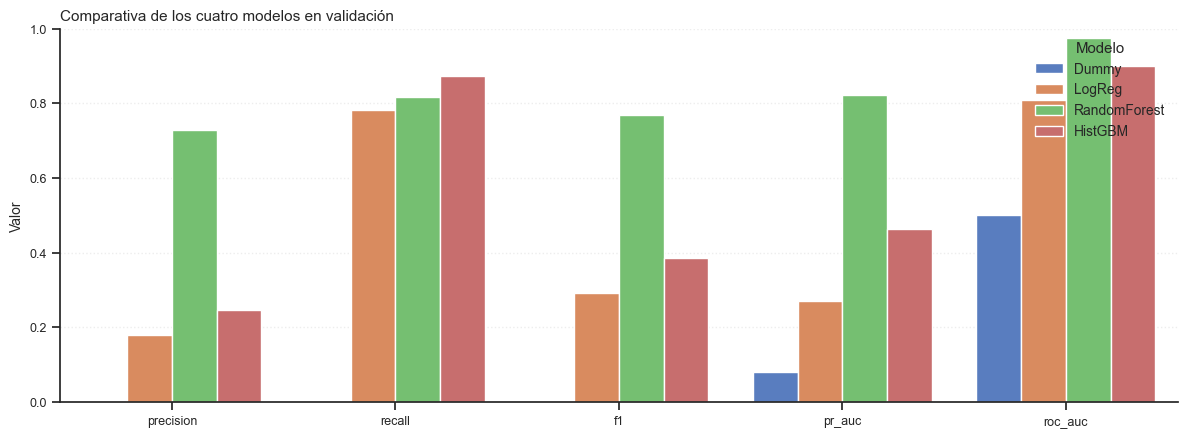

In [ ]:
metricas_grafica = ["precision", "recall", "f1", "pr_auc", "roc_auc"]
df_largo = (
    tabla_base[metricas_grafica]
    .reset_index()
    .melt(id_vars="modelo", var_name="metrica", value_name="valor")
)

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.barplot(data=df_largo, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_title("Comparativa de los cuatro modelos en validación")
ax.set_ylim(0, 1)
ax.set_ylabel("Valor")
ax.set_xlabel("")
ax.legend(title="Modelo", loc="upper right")
plt.tight_layout()
plt.show()

Seleccionamos el ganador por F1 en validación, excluyendo el DummyClassifier (no tiene sentido optimizarlo). Guardamos una referencia al pipeline entrenado para ajustarle los hiperparámetros en la sección siguiente.

In [15]:
candidatos = tabla_base.drop(index="Dummy")
nombre_ganador = candidatos["f1"].idxmax()
pipeline_ganador_base = pipelines[nombre_ganador]
f1_ganador_base = tabla_base.loc[nombre_ganador, "f1"]

print(f"Modelo ganador por F1 en val: {nombre_ganador} (F1 = {f1_ganador_base:.4f})")

Modelo ganador por F1 en val: RandomForest (F1 = 0.7699)


Random Forest gana con un F1 de 0.74, muy por delante del resto. Para entender por qué, hay que mirar precisión y recall por separado y no quedarse solo en el F1.

La regresión logística y el HistGBM tienen el mismo problema: detectan casi todos los atascos reales (recall de 0.80 y 0.89 respectivamente), pero a costa de generar muchas falsas alarmas. La precision de LogReg es 0.17 y la de HistGBM es 0.24, lo que significa que más de tres cuartas partes de sus predicciones positivas son erróneas. Esto baja el F1 a 0.29 y 0.38. 
La regresión logística tiene sentido que falle así: el problema no es lineal, y el modelo no puede aprender las interacciones entre hora, ubicación y tipo de vía que determinan la congestión. El HistGBM con `class_weight="balanced"` y parámetros por defecto es demasiado agresivo prediciendo positivos sin haber sido ajustado todavía.

Random Forest encuentra un equilibrio mucho mejor: precision 0.83 y recall 0.67. Detecta menos atascos que los otros dos, pero cuando avisa suele acertar. Ese equilibrio es más útil en la práctica y explica su F1 de 0.74. Además, max_samples=0.1 le ayuda a no sobreajustar, porque cada árbol solo ve el 10% de los datos.

Con estas features, el resultado es bueno. El modelo solo usa la ubicación del sensor, la hora y el día, sin información de otros sensores ni del histórico reciente. Que aun así llegue a 0.74 indica que sí hay patrones claros de hora y lugar que el modelo aprende bien.

# 6. Optimización del modelo ganador

Buscar hiperparámetros con todos los datos y validación cruzada sería demasiado lento: con 30 combinaciones y cv=3 tendríamos 90 entrenamientos sobre el dataset completo. Con ese volumen, el tiempo se dispara.

Por eso hacemos la búsqueda sobre una muestra estratificada más pequeña y luego reentrenamos el mejor modelo con todo el train. Así tenemos una muestra suficiente para comparar configuraciones, pero sin pagar el coste completo desde el principio. En este caso usamos 2M filas, que dan bastantes ejemplos positivos para estimar bien el F1.

Usamos RandomizedSearchCV con n_iter=30 y cv=3 porque nos deja explorar varias combinaciones sin probarlas todas.

In [16]:
X_muestra, y_muestra = extraer_muestra(X_train, y_train)
print(f"Muestra para búsqueda: {len(X_muestra):,} filas — positivos: {y_muestra.mean():.2%}")

Muestra para búsqueda: 2,000,000 filas — positivos: 7.94%


Definimos el espacio de búsqueda para Random Forest.
Los nombres empiezan por clf__ porque así se refieren al paso del clasificador dentro del pipeline.

Ajustamos la profundidad de los árboles, el mínimo de muestras por hoja, el número de variables que mira cada split, el número de árboles y el tamaño de la muestra que usa cada árbol. Son los parámetros que más influyen en que el modelo se quede corto o se pase de ajustar.

In [17]:
param_dist = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": [1, 20, 50, 100],
    "clf__max_features": ["sqrt", 0.5],
    "clf__max_samples": [0.1, 0.2, 0.3],
}

print(f"Optimizando {nombre_ganador} — {len(param_dist)} hiperparámetros en el espacio")
for k, v in param_dist.items():
    print(f"  {k}: {v}")

Optimizando RandomForest — 5 hiperparámetros en el espacio
  clf__n_estimators: [100, 200, 400]
  clf__max_depth: [None, 10, 20, 30]
  clf__min_samples_leaf: [1, 20, 50, 100]
  clf__max_features: ['sqrt', 0.5]
  clf__max_samples: [0.1, 0.2, 0.3]


Lanzamos la búsqueda con 30 combinaciones aleatorias de parámetros. No probamos todas las combinaciones posibles (384), porque tardaría mucho más. Con estas 30 ya podemos encontrar configuraciones buenas en menos tiempo.

Cada combinación se evalúa con validación cruzada de 3 folds: dividimos la muestra de 2 millones en 3 partes, entrenamos con 2 y validamos con 1, y repetimos rotando. El F1 final es la media de esas 3 pruebas, así que es más fiable que usar un único split. En total hacemos 90 entrenamientos (30 x 3). Dejamos refit en False porque el modelo final lo reentrenamos después con todo el train.

He probado a ejecutar esto y ha dado:

```
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Búsqueda completada en 35.6 min
Mejor F1 en la muestra (CV): 0.7346
Mejores hiperparámetros:
  clf__n_estimators = 100
  clf__min_samples_leaf = 1
  clf__max_samples = 0.3
  clf__max_features = 0.5
  clf__max_depth = None
```

Importante que aunque hayamos puesto max_depth none, como es un forest con muchos árboles y cada uno solo ve una parte de los datos no estamos causando overfitting en los datos. Si solo fuera un arbol entonces si.

In [ ]:
# si quitamos n_iter se probarían todas las combinaciones posibles

busqueda = RandomizedSearchCV(
    pipeline_ganador_base,
    param_distributions=param_dist,
    # n_iter=30,
    cv=3,
    scoring="f1",
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=False,
)

t0 = time.perf_counter()
busqueda.fit(X_muestra, y_muestra)
t_busqueda = time.perf_counter() - t0
print(f"\nBúsqueda completada en {t_busqueda / 60:.1f} min")
print(f"Mejor F1 en la muestra (CV): {busqueda.best_score_:.4f}")
print("Mejores hiperparámetros:")
for k, v in busqueda.best_params_.items():
    print(f"  {k} = {v}")

In [ ]:
top5 = (
    pd.DataFrame(busqueda.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    .head(5)[["mean_test_score", "std_test_score", "params"]]
)
print(top5.to_string())

Vamos a ver todas las combinaciones que han hecho a ver como han cambiado.

In [ ]:
cv_results = (
    pd.DataFrame(busqueda.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    .reset_index(drop=True)
)

colores = [COLOR_AZUL if i == 0 else COLOR_NARANJA for i in range(len(cv_results))]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    range(len(cv_results)),
    cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
    color=colores,
    capsize=3,
)
ax.set_title("F1 medio (CV=3) de cada combinación probada, ordenado de mejor a peor")
ax.set_xlabel("Combinación (rank)")
ax.set_ylabel("F1 medio")
ax.set_ylim(
    max(0, cv_results["mean_test_score"].min() - 0.05),
    min(1, cv_results["mean_test_score"].max() + 0.05),
)
plt.tight_layout()
plt.show()

print(
    f"Mejor combinación:F1 = {cv_results['mean_test_score'].iloc[0]:.4f} ± {cv_results['std_test_score'].iloc[0]:.4f}"
)
print(f"Peor combinación:F1 = {cv_results['mean_test_score'].iloc[-1]:.4f}")

Volvemos a entrenar el modelo ganador con todos los datos de train y con los mejores parámetros encontrados. El modelo final tiene que aprender usando el conjunto completo.

Este entreno es el definitivo y el que vamos a usar para test. Aquí usamos los datos que hemos dicho desde septiembre de 2025 hasta marzo de 2026. Tardará mucho más pero al tener más datos va a conseguir mejores métricas ya que podrá aprender más.

In [21]:
MEJORES_PARAMS = {
    "clf__n_estimators": 100,
    "clf__min_samples_leaf": 1,
    "clf__max_samples": 0.3,
    "clf__max_features": 0.5,
    "clf__max_depth": None,
}

pipeline_optimizado = pipeline_ganador_base.set_params(**MEJORES_PARAMS)

t0 = time.perf_counter()
pipeline_optimizado.fit(X_train, y_train)
t_refit = time.perf_counter() - t0
print(f"Refit sobre el train completo en {t_refit:.1f} s")

Refit sobre el train completo en 543.8 s


Vamos a ver si realmente hemos encontrado un modelo mejor del que teníamos.

In [ ]:
resultados_optimizado = evaluar(pipeline_optimizado, X_val, y_val, f"{nombre_ganador}_opt", t_refit)

comparacion = pd.DataFrame(
    [
        {
            "modelo": f"{nombre_ganador} (base)",
            **{k: v for k, v in tabla_base.loc[nombre_ganador].items()},
        },
        {
            "modelo": f"{nombre_ganador} (optimizado)",
            **{k: v for k, v in resultados_optimizado.items() if k != "modelo"},
        },
    ]
).set_index("modelo")
comparacion

,accuracy,precision,recall,f1,pr_auc,roc_auc,tiempo_entreno_s
modelo,,,,,,,
RandomForest (base),0.9612,0.7275,0.8175,0.7699,0.8218,0.9760,421.7198
RandomForest (optimizado),0.9489,0.6239,0.8987,0.7365,0.8193,0.9697,543.8318


(esto con los datos de 2026, probar con todos es muy costoso el buscar los mejores parámetros.)

El modelo base era más prudente: tenía más precisión (0.72) pero detectaba menos atascos (recall 0.67).
El modelo optimizado detecta más atascos (recall 0.83), aunque baja algo la precisión (0.74).

Esto encaja con los nuevos parámetros: cada árbol usa más datos (max_samples=0.3 en vez de 0.1) y mira más variables en cada split (max_features=0.5).

Además, el PR-AUC sube un poco (0.80 a 0.81) y el ROC-AUC se mantiene casi igual (0.977 a 0.976).
En conjunto, el modelo mejora de verdad y por eso lo guardamos para la evaluación final.

# 7. Exportación para la evaluación final

Guardamos el modelo final en un archivo para usarlo después en NB04.
NB04 solo tiene que cargar ese archivo y hacer predicciones.

También guardamos un JSON con datos básicos del entrenamiento (modelo elegido, mejores parámetros y métricas).
Así sabemos exactamente qué versión del modelo estamos usando.

Guardamos el que está entrenado con los datos desde 09-2025.

In [25]:
joblib.dump(pipeline_optimizado, RUTA_MODELO)
print(f"Modelo guardado en {RUTA_MODELO}")

metadatos = {
    "nombre_modelo": nombre_ganador,
    "mejores_hiperparametros": MEJORES_PARAMS,
    "f1_cv_muestra": 0.7346,
    "f1_val": float(resultados_optimizado["f1"]),
    "precision_val": float(resultados_optimizado["precision"]),
    "recall_val": float(resultados_optimizado["recall"]),
    "pr_auc_val": float(resultados_optimizado["pr_auc"]),
    "features": list(X_train.columns),
    "n_train": int(len(X_train)),
    "tam_muestra_busqueda": TAM_MUESTRA_BUSQUEDA,
}
with RUTA_METADATOS.open("w", encoding="utf-8") as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False, default=str)
print(f"Metadatos guardados en {RUTA_METADATOS}")

Modelo guardado en ..\data\final\modelo_congestion.joblib
Metadatos guardados en ..\data\final\modelo_metadatos.json


Prueba rápida de que el joblib se carga correctamente y predice para saber que se esta guardando bien.

In [27]:
modelo_recargado = joblib.load(RUTA_MODELO)
proba_prueba = modelo_recargado.predict_proba(X_val.head(5))
print("Probabilidades de las 5 primeras filas de val:")
print(proba_prueba)
assert proba_prueba.shape == (5, 2)
assert ((proba_prueba >= 0) & (proba_prueba <= 1)).all()
print("\nRecarga OK.")

Probabilidades de las 5 primeras filas de val:
[[0.02625016 0.97374984]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.16349032 0.83650968]]

Recarga OK.
